<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/ML_Projects/Scam%20Detection/Scam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("noorsaeed/scam-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 207k/207k [00:00<00:00, 37.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/noorsaeed/scam-detection-dataset/versions/1


In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("SMS Spam Dataset.csv")
df.head()

Saving SMS Spam Dataset.csv to SMS Spam Dataset.csv


,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
df.shape


(5574, 2)

In [8]:
df.isnull().sum()

,0
sms,0
label,0


In [10]:
%%markdown
---
Graph 1 - N-Gram Analysis

---
Graph 1 - N-Gram Analysis


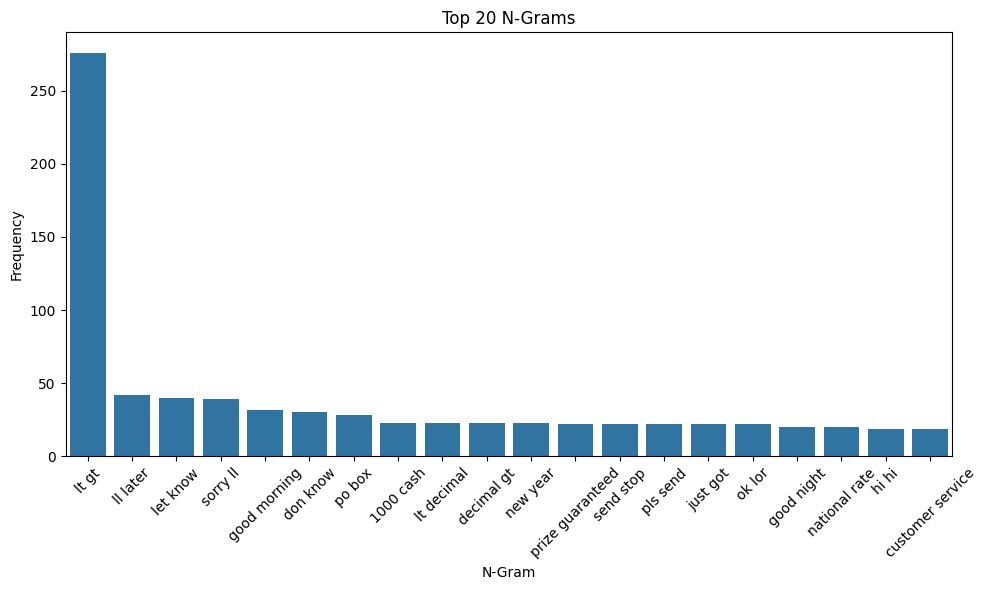

In [9]:
# Top N-Grams Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer


cv = CountVectorizer(ngram_range=(2, 2), stop_words='english')
X = cv.fit_transform(df['sms'])
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]
top_ngrams = [word[0] for word in words_freq]
plt.figure(figsize=(10, 6))
sns.barplot(x=[word[0] for word in words_freq], y=[word[1] for word in words_freq])
plt.title('Top 20 N-Grams')
plt.xlabel('N-Gram')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
%%markdown
---
Graph 2 - Classes Distribution

---
Graph 2 - Classes Distribution


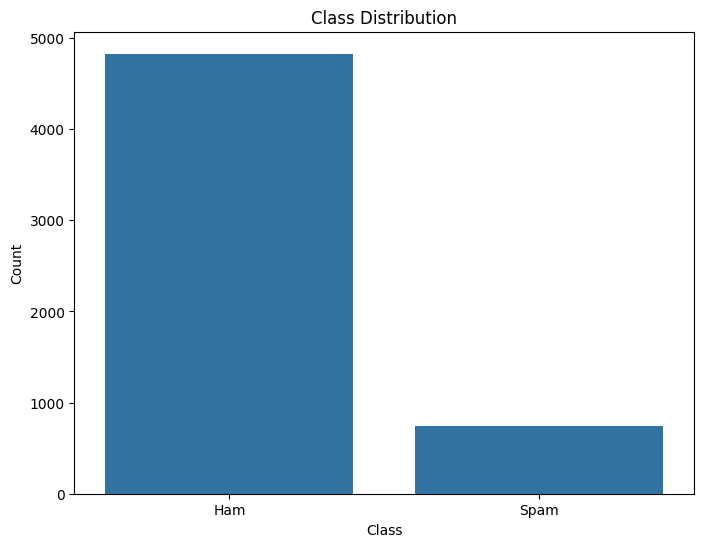

In [12]:
# Plot class distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.show()

In [13]:
%%markdown
---
Graph 3: Messages Length Distribution

---
Graph 3: Messages Length Distribution


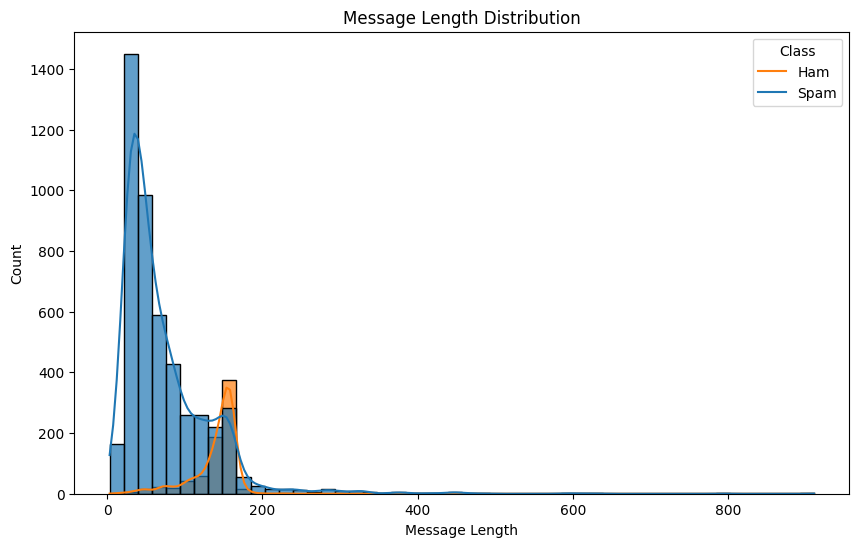

In [14]:
# Plot message length distribution
df['message_length'] = df['sms'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, alpha=0.7)
plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Count')
plt.legend(title='Class', labels=['Ham', 'Spam'])
plt.show()

In [15]:
%%markdown
---
Graph 4 - Word Clouds for both spam and hem messages

---
Graph 4 - Word Clouds for both spam and hem messages


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


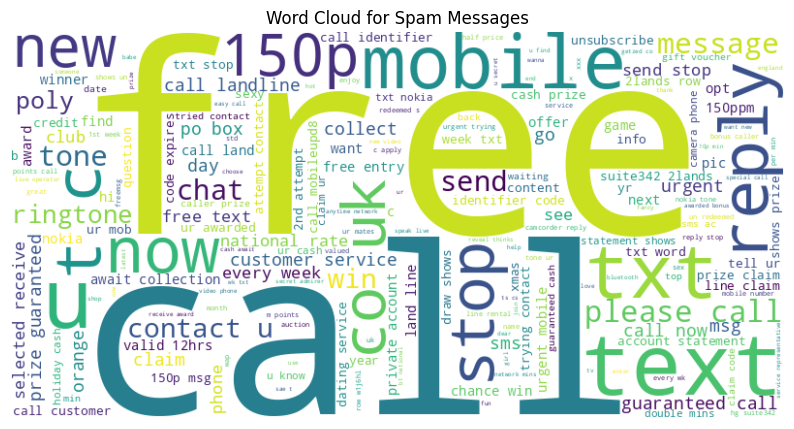

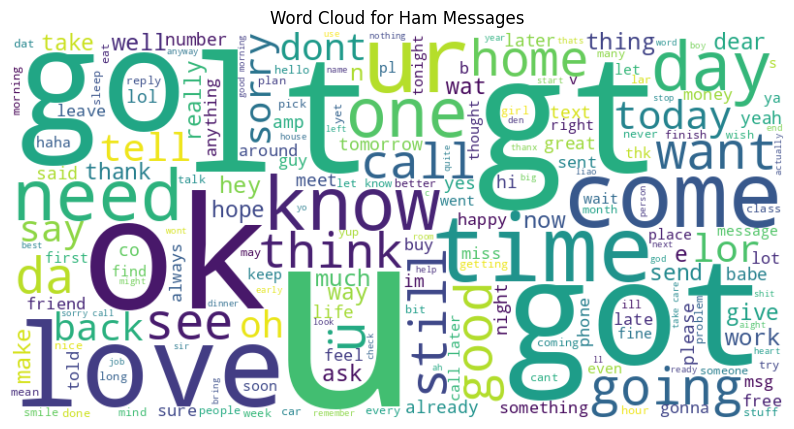

In [17]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Remove stopwords from spam and ham messages
spam_messages = df[df['label'] == 1]['sms'].str.lower().apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
ham_messages = df[df['label'] == 0]['sms'].str.lower().apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

# Generate word cloud for spam messages
plt.figure(figsize=(10, 8))
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(' '.join(spam_messages))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Word Cloud for Spam Messages')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 8))
wordcloud_ham = WordCloud(width=800, height=400, background_color='white').generate(' '.join(ham_messages))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title('Word Cloud for Ham Messages')
plt.axis('off')
plt.show()

In [18]:
%%markdown
---
Cleaning Text

---
Cleaning Text


In [21]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download required resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    filtered_words = [w for w in words if w not in stop_words]

    stemmer = PorterStemmer()
    stemmed_words = [stemmer.stem(w) for w in filtered_words]

    return ' '.join(stemmed_words)

df['clean_text'] = df['sms'].apply(clean_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
%%markdown
---
Data Balancing

---
Data Balancing


In [23]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler

X = df.drop('label', axis=1)
y = df['label']

oversampler = RandomOverSampler()

X_resampled, y_resampled = oversampler.fit_resample(X, y)

df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['label'] = y_resampled

df_balanced['label'].value_counts()

,count
label,
0,4827
1,4827


In [24]:
%%markdown
---
Train Test Split and TFIDF Vectorization

---
Train Test Split and TFIDF Vectorization


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(df_balanced['clean_text'], df_balanced['label'], test_size=0.2, random_state=42)

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [27]:
X_train_tfidf.shape

(7723, 6488)

In [28]:
%%markdown
---
Model building and ensemble Learning

---
Model building and ensemble Learning
